<a href="https://colab.research.google.com/github/jetisaplane1/AI-for-Business-BUS4-118S/blob/dev/DVGAI_Module_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded: /content/adult-all-1.csv
Shape: (48841, 15)
---- INFO ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48841 entries, 0 to 48840
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   39             48841 non-null  int64 
 1   State-gov      48841 non-null  object
 2   77516          48841 non-null  int64 
 3   Bachelors      48841 non-null  object
 4   13             48841 non-null  int64 
 5   Never-married  48841 non-null  object
 6   Adm-clerical   48841 non-null  object
 7   Not-in-family  48841 non-null  object
 8   White          48841 non-null  object
 9   Male           48841 non-null  object
 10  2174           48841 non-null  int64 
 11  0              48841 non-null  int64 
 12  40             48841 non-null  int64 
 13  United-States  48841 non-null  object
 14  <=50K          48841 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None

---- MISSING (including '?') ----
Adm

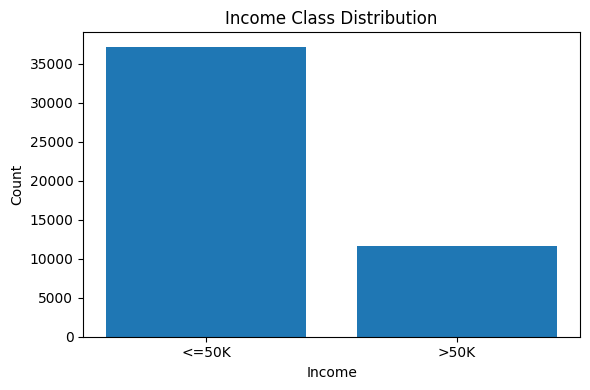

Saved: charts/viz1_income_distribution.png
✅ Detected age column: 39
Age non-null count: 48841
Age min/median/max: 17 37 90


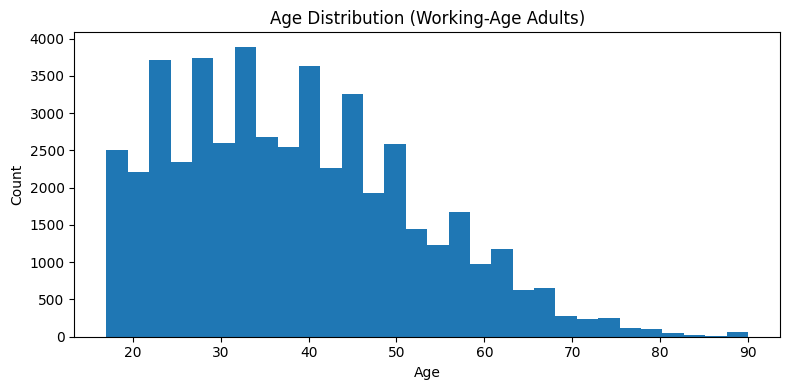

Saved: charts/viz2_age_hist.png
✅ Income column: <=50K
✅ Age column: 39


/tmp/ipython-input-1857726894.py:326: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


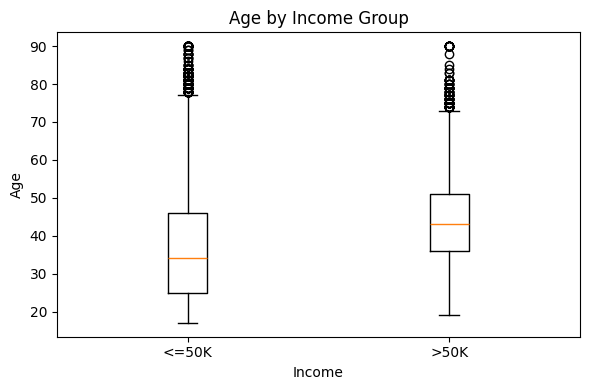

Saved: charts/viz3_age_by_income_box.png
['39', 'State-gov', '77516', 'Bachelors', '13', 'Never-married', 'Adm-clerical', 'Not-in-family', 'White', 'Male', '2174', '0', '40', 'United-States', '<=50K']
Available columns:
['39', 'State-gov', '77516', 'Bachelors', '13', 'Never-married', 'Adm-clerical', 'Not-in-family', 'White', 'Male', '2174', '0', '40', 'United-States', '<=50K']


KeyError: 'income'

In [ ]:
# =========================================
# 0) Setup + Load
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path


csv_path = Path("/content/adult-all-1.csv")

if not csv_path.exists():
    csv_path = Path("adult-all-1.csv")

df = pd.read_csv(csv_path)

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Strip whitespace from string cells (common issue in Adult dataset)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print("Loaded:", csv_path)
print("Shape:", df.shape)
df.head()

# =========================================
# 1) Data Exploration (initial structure + summaries)
# =========================================

print("---- INFO ----")
print(df.info())

print("\n---- MISSING (including '?') ----")
# Convert "?" to NaN first so missing stats are accurate
df_exp = df.copy()
df_exp.replace("?", np.nan, inplace=True)

missing = df_exp.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

# Identify numeric vs categorical columns
num_cols = df_exp.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_exp.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)

print("\n---- NUMERIC SUMMARY ----")
print(df_exp[num_cols].describe().T)

print("\n---- INCOME DISTRIBUTION (if income column exists) ----")
income_col_guess = None
for candidate in ["income", "Income", "class", "salary"]:
    if candidate in df_exp.columns:
        income_col_guess = candidate
        break

if income_col_guess:
    print(df_exp[income_col_guess].value_counts(dropna=False))
else:
    print("No obvious income column found. Columns are:", df_exp.columns.tolist())

print("\n---- TOP CATEGORIES (first 10 each) ----")
for c in cat_cols:
    print(f"\n{c} (top 10):")
    print(df_exp[c].value_counts(dropna=False).head(10))

# =========================================
# 2) Data Cleaning (missing values + outliers handling)
# =========================================

df_clean = df.copy()

# Replace '?' with NaN
df_clean.replace("?", np.nan, inplace=True)

# If income column exists, standardize it (remove periods if present like '>50K.')
income_col = income_col_guess
if income_col:
    df_clean[income_col] = df_clean[income_col].astype(str).str.replace(".", "", regex=False).str.strip()

# Drop rows missing key categorical fields (common for Adult dataset)
# Adjust these if your dataset uses different column names
key_cols = [c for c in ["workclass", "occupation", "native-country"] if c in df_clean.columns]
before = len(df_clean)
if key_cols:
    df_clean = df_clean.dropna(subset=key_cols).copy()
after = len(df_clean)

print(f"Dropped {before - after} rows due to missing in {key_cols}")

# Outlier handling approach:
# We'll NOT delete outliers aggressively (bad for storytelling).
# Instead, we will use:
#  - boxplots to show outliers
#  - log transform for skewed variables like capital-gain
skew_candidates = [c for c in ["capital-gain", "capital-loss"] if c in df_clean.columns]
for c in skew_candidates:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# Ensure numeric columns are numeric
for c in num_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

print("Clean shape:", df_clean.shape)
df_clean.head()

# =========================================
# Helper function: save charts
# =========================================
import os
output_dir = "charts"
os.makedirs(output_dir, exist_ok=True)

def save_show(fig_name: str):
    path = os.path.join(output_dir, fig_name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# 1) Helper: make sure charts display + save
# -----------------------------
output_dir = "charts"
os.makedirs(output_dir, exist_ok=True)

def save_show(fig_name: str):
    path = os.path.join(output_dir, fig_name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# -----------------------------
# 2) Robustly detect the income column
#    (Find a column that contains values like '<=50K' or '>50K')
# -----------------------------
def detect_income_column(df: pd.DataFrame) -> str:
    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        # Convert to string safely and strip spaces
        vals = df[c].dropna().astype(str).str.strip().unique()
        joined = " ".join(vals)
        if ("<=50K" in joined) or (">50K" in joined) or ("<=50K." in joined) or (">50K." in joined):
            return c
    return None

income_col = detect_income_column(df_clean)

# If still not found, print columns so you can set it manually
if income_col is None:
    print("❌ Could not auto-detect income column.")
    print("Columns are:", df_clean.columns.tolist())
    # If you see the correct column name above, uncomment and set it:
    # income_col = "income"
else:
    print("✅ Detected income column:", income_col)

# Standardize income values (remove trailing periods like '>50K.')
if income_col is not None:
    df_clean[income_col] = (
        df_clean[income_col]
        .astype(str)
        .str.strip()
        .str.replace(".", "", regex=False)
    )

# -----------------------------
# 3) VIZ 1 (FINAL REPORT): Income Distribution Bar Chart
# -----------------------------
if income_col is None:
    raise ValueError("Income column not found. Set income_col manually based on printed columns above.")

counts = df_clean[income_col].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

save_show("viz1_income_distribution.png")

# -----------------------------
# Robustly detect the age column
# -----------------------------
def detect_age_column(df: pd.DataFrame) -> str:
    # First try common names
    for cand in ["age", "Age", "AGE"]:
        if cand in df.columns:
            return cand

    # Otherwise, look for a numeric-like column whose name contains "age"
    for c in df.columns:
        if "age" in str(c).lower():
            return c

    # As a last resort, search numeric columns for plausible age range
    for c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().sum() > 0:
            # Typical adult ages are ~17-90; allow slightly wider
            if s.min() >= 0 and s.max() <= 100:
                # Heuristic: many unique values suggests continuous age
                if s.nunique() > 30:
                    return c
    return None

age_col = detect_age_column(df_clean)

if age_col is None:
    raise ValueError("Could not find an age column. Print df_clean.columns and identify it manually.")

print("✅ Detected age column:", age_col)

# Ensure age is numeric
age_series = pd.to_numeric(df_clean[age_col], errors="coerce").dropna()

# Safety check: make sure we have data
print("Age non-null count:", age_series.shape[0])
print("Age min/median/max:", int(age_series.min()), int(age_series.median()), int(age_series.max()))

if age_series.shape[0] == 0:
    raise ValueError("Age column exists but has no numeric values after conversion.")

# -----------------------------
# Viz 2: Age Distribution Histogram
# -----------------------------
plt.figure(figsize=(8,4))

# Bins chosen for readability of "working-age adults"
# Range caps make the plot cleaner and match the narrative (avoid extreme outliers)
plt.hist(age_series[(age_series >= 15) & (age_series <= 90)], bins=30)

plt.title("Age Distribution (Working-Age Adults)")
plt.xlabel("Age")
plt.ylabel("Count")

save_show("viz2_age_hist.png")

# -----------------------------
# Detect income column (<=50K / >50K)
# -----------------------------
def detect_income_column(df: pd.DataFrame) -> str:
    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        vals = df[c].dropna().astype(str).str.strip().unique()
        joined = " ".join(vals)
        if ("<=50K" in joined) or (">50K" in joined) or ("<=50K." in joined) or (">50K." in joined):
            return c
    return None

# -----------------------------
# Detect age column
# -----------------------------
def detect_age_column(df: pd.DataFrame) -> str:
    for cand in ["age", "Age", "AGE"]:
        if cand in df.columns:
            return cand
    for c in df.columns:
        if "age" in str(c).lower():
            return c
    # last resort: numeric column that looks like age range
    for c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().sum() > 0 and s.min() >= 0 and s.max() <= 100 and s.nunique() > 30:
            return c
    return None

income_col = detect_income_column(df_clean)
age_col = detect_age_column(df_clean)

if income_col is None:
    raise ValueError("Could not detect income column (needs values like <=50K or >50K).")
if age_col is None:
    raise ValueError("Could not detect age column.")

print("✅ Income column:", income_col)
print("✅ Age column:", age_col)

# Standardize income labels (remove trailing period)
df_clean[income_col] = (
    df_clean[income_col].astype(str).str.strip().str.replace(".", "", regex=False)
)

# Make sure age is numeric
df_clean[age_col] = pd.to_numeric(df_clean[age_col], errors="coerce")

# Order income groups so the plot matches the narrative: <=50K then >50K (if present)
unique_incomes = df_clean[income_col].dropna().unique().tolist()
labels_order = []
if "<=50K" in unique_incomes:
    labels_order.append("<=50K")
if ">50K" in unique_incomes:
    labels_order.append(">50K")
# include any other unexpected labels at the end
for v in unique_incomes:
    if v not in labels_order:
        labels_order.append(v)

# Build groups
groups = []
labels = []
for lab in labels_order:
    series = df_clean.loc[df_clean[income_col] == lab, age_col].dropna()
    if len(series) > 0:
        groups.append(series)
        labels.append(lab)

if len(groups) < 2:
    raise ValueError(f"Not enough income groups with age data to plot. Found labels: {labels}")

# -----------------------------
# Viz 3: Age by Income (Box Plot)
# -----------------------------
plt.figure(figsize=(6,4))
plt.boxplot(groups, labels=labels, showfliers=True)
plt.title("Age by Income Group")
plt.xlabel("Income")
plt.ylabel("Age")

save_show("viz3_age_by_income_box.png")

#---------
print(df_clean.columns.tolist())

# -----------------------------
# PRINT COLUMNS (for safety)
# -----------------------------
print("Available columns:")
print(df_clean.columns.tolist())

# -----------------------------
# MANUALLY SET COLUMNS (MOST RELIABLE)
# -----------------------------
income_col = "income"          # change ONLY if your print shows a different name
education_col = "education"    # change ONLY if your print shows a different name

# If your column is 'education ' (with space), use:
# education_col = "education "

# If your dataset truly does NOT have categorical education,
# STOP and tell me what columns you see.

# -----------------------------
# Clean income labels
# -----------------------------
df_clean[income_col] = (
    df_clean[income_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# Identify high-income label
high_label = ">50K"

# -----------------------------
# Build % >50K by education
# -----------------------------
edu_tab = (
    pd.crosstab(df_clean[education_col], df_clean[income_col], normalize="index") * 100
)

edu_pct_high = edu_tab[high_label].sort_values(ascending=False)

# Limit categories so chart is readable
top_n = 16
edu_pct_plot = edu_pct_high.head(top_n)

# -----------------------------
# Viz 4: Education vs Income
# -----------------------------
plt.figure(figsize=(10,4))
plt.bar(edu_pct_plot.index.astype(str), edu_pct_plot.values)
plt.title("Percent Earning >50K by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percent >50K")
plt.xticks(rotation=45, ha="right")

save_show("viz4_education_pct_highincome.png")
print(df_clean.columns.tolist())
